**Name:** Muhammad Khizar Bin Muzaffar


# Importing Libraries

In [80]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np



In [81]:
data = pd.read_csv("https://raw.githubusercontent.com/Khizar-BM/ML-Mini-Project-1/main/bank-additional-full.csv", sep=';')

In [82]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [83]:
# Exploratory Data Analysis
eda_summary = {
    "Data Shape": data.shape,
    "Missing Values": data.isnull().sum(),
    "Unique Values": data.nunique(),
    "Data Types": data.dtypes
}

# Check for any obvious imbalances in the target variable
target_balance = data['y'].value_counts(normalize=True) * 100

eda_summary, target_balance

({'Data Shape': (41188, 21),
  'Missing Values': age               0
  job               0
  marital           0
  education         0
  default           0
  housing           0
  loan              0
  contact           0
  month             0
  day_of_week       0
  duration          0
  campaign          0
  pdays             0
  previous          0
  poutcome          0
  emp.var.rate      0
  cons.price.idx    0
  cons.conf.idx     0
  euribor3m         0
  nr.employed       0
  y                 0
  dtype: int64,
  'Unique Values': age                 78
  job                 12
  marital              4
  education            8
  default              3
  housing              3
  loan                 3
  contact              2
  month               10
  day_of_week          5
  duration          1544
  campaign            42
  pdays               27
  previous             8
  poutcome             3
  emp.var.rate        10
  cons.price.idx      26
  cons.conf.idx       26
  euribo

The exploratory data analysis provides several insights:

- Data Shape: The dataset contains 41,188 rows and 21 columns.
- Missing Values: There are no missing values in the dataset. However, some columns like 'job', 'marital', 'education', etc., have 'unknown' categories which might need special handling.
- Unique Values: The dataset has a mix of categorical and numerical variables, with varying numbers of unique values.
- Data Types: Most features are categorical (object type) with some numerical features (int64 and float64).
- Target Variable Balance: The target variable 'y' shows that about 88.73% of the clients did not subscribe to a term deposit, while 11.27% did. This indicates a class imbalance which may affect model performance.

**Next Steps for Preprocessing**
- Handling 'Unknown' Values: We need to decide how to handle 'unknown' values in categorical features. Depending on their proportion, we might impute them, treat them as a separate category, or drop them if they are in small numbers.

- Encoding Categorical Variables: We'll convert these into a format suitable for machine learning algorithms using one-hot encoding

- Dealing with Class Imbalance: Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights in the model can be considered.

- Feature Scaling: Standardizing or normalizing the numerical variables to ensure they're on the same scale.

- Feature Selection: We will exclude 'duration' from the model training as per the dataset's note.

# Data Preprocessing

## Handling Missing Values, Encoding Categorical Variables and Feature Scaling



In [84]:
# Columns for one-hot encoding and standardization
categorical_cols = data.select_dtypes(include=['object']).columns.drop('y')
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('duration')

# Pipelines for transformation
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Applying preprocessing
X = data.drop(['y', 'duration'], axis=1)
y = data['y']
X_preprocessed = preprocessor.fit_transform(X)

# Get the feature names after transformation
feature_names = list(numerical_cols) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))

# Assigning feature names to preprocessed data
X_preprocessed = pd.DataFrame(X_preprocessed, columns=feature_names)
# Encoding the target variable
y_encoded = y.apply(lambda x: 1 if x == 'yes' else 0)

In [85]:
X_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  float64
 1   campaign                       41188 non-null  float64
 2   pdays                          41188 non-null  float64
 3   previous                       41188 non-null  float64
 4   emp.var.rate                   41188 non-null  float64
 5   cons.price.idx                 41188 non-null  float64
 6   cons.conf.idx                  41188 non-null  float64
 7   euribor3m                      41188 non-null  float64
 8   nr.employed                    41188 non-null  float64
 9   job_admin.                     41188 non-null  float64
 10  job_blue-collar                41188 non-null  float64
 11  job_entrepreneur               41188 non-null  float64
 12  job_housemaid                  41188 non-null 

After preprocessing, the dataset now has 41,188 rows and 62 features.

# Feature Selection

Top 10 feature rankings:
1. age: 0.16291408655500042
2. euribor3m: 0.11730340992799283
3. campaign: 0.08383158362228262
4. nr.employed: 0.04762425762389976
5. pdays: 0.03158248856559027
6. cons.conf.idx: 0.02747865122315413
7. emp.var.rate: 0.026545986549023542
8. poutcome_success: 0.023067522151904066
9. housing_yes: 0.02112540855322526
10. housing_no: 0.02078685614786081


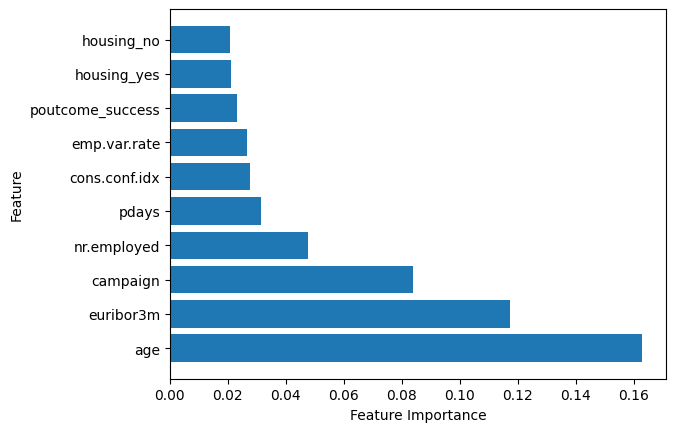

['age', 'euribor3m', 'campaign', 'nr.employed', 'pdays', 'cons.conf.idx', 'emp.var.rate', 'poutcome_success', 'housing_yes', 'housing_no']


In [86]:
# Create a random forest classifier object
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rfc.fit(X_preprocessed, y_encoded)

# Get feature importances from the trained model
importances = rfc.feature_importances_

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

important_features = []


# Select the top 10 features
num_features = 10
top_indices = indices[:num_features]
top_importances = importances[top_indices]


# Print the top 10 feature rankings
print("Top 10 feature rankings:")
for f in range(num_features):  # Use num_features instead of 10
    print(f"{f+1}. {X_preprocessed.columns[indices[f]]}: {importances[indices[f]]}")
    important_features.append(X_preprocessed.columns[indices[f]])
# Plot the top 10 feature importances in a horizontal bar chart
plt.barh(range(num_features), top_importances, align="center")
plt.yticks(range(num_features), X_preprocessed.columns[top_indices])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()
print(important_features)

# Modelling

In [103]:
def visualize_model_metrics(model_metrics):
    """
    Visualize the model metrics in a single graph as a grouped bar chart.

    Parameters:
    model_metrics (dict): A dictionary containing the evaluation metrics for each model.
    """
    metrics = list(next(iter(model_metrics.values())).keys())
    models = list(model_metrics.keys())
    n_metrics = len(metrics)
    n_models = len(models)

    # Data preparation for grouped bar chart
    barWidth = 0.15  # Width of the bars
    r = np.arange(n_models)  # Positions of bars on the x-axis

    # Create a figure
    plt.figure(figsize=(12, 8))

    for i, metric in enumerate(metrics):
        # Set position of bar on X axis
        pos = [x + barWidth * i for x in r]

        # Make the plot
        values = [model_metrics[model][metric] for model in models]
        plt.bar(pos, values, width=barWidth, edgecolor='grey', label=metric)

    # Add xticks on the middle of the group bars
    plt.xlabel('Model', fontweight='bold')
    plt.xticks([r + barWidth for r in range(n_models)], models)
    plt.ylim(0, 1)  # Assuming metric values range from 0 to 1
    plt.ylabel('Scores')
    plt.title('Model Evaluation Metrics Comparison')

    # Create legend & Show graphic
    plt.legend(metrics, loc='upper left')
    plt.show()


In [104]:
def evaluate_models_with_stratified_kfold(models, X, y, n_splits=5, oversample=False):
    """
    Evaluate multiple models using Stratified K-Fold cross-validation and calculate
    average precision, recall, F1-score, accuracy, and ROC-AUC for each model.

    Parameters:
    models: A dictionary of models to evaluate, with model names as keys and model instances as values.
    X: Features (independent variables).
    y: Target variable.
    n_splits: Number of splits for the StratifiedKFold.
    """

    # Initialize StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    # Dictionary to store the average metrics for each model
    model_metrics = {}


    # Iterate over each model
    for name, model in models.items():
        print(f"Evaluating model: {name}")

        # Lists to store metrics for each fold
        precisions, recalls, f1s, accuracies, roc_aucs = [], [], [], [], []

        for train_index, test_index in skf.split(X, y):
            # Splitting the data
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            # Apply SMOTE
            if oversample:
              smote = SMOTE(random_state=42)
              X_train, y_train = smote.fit_resample(X_train, y_train)

            # Fit the model
            model.fit(X_train, y_train)

            # Make predictions
            y_pred = model.predict(X_test)

            # Calculate metrics
            precisions.append(precision_score(y_test, y_pred))
            recalls.append(recall_score(y_test, y_pred))
            f1s.append(f1_score(y_test, y_pred, average='macro'))
            accuracies.append(accuracy_score(y_test, y_pred))
            roc_aucs.append(roc_auc_score(y_test, y_pred))

        # Calculate and print the average of each metric
        print("Average Precision:", np.mean(precisions))
        print("Average Recall:", np.mean(recalls))
        print("Average F1-Score:", np.mean(f1s))
        print("Average Accuracy:", np.mean(accuracies))
        print("Average ROC-AUC:", np.mean(roc_aucs))
        print("\n")  # New line for better readability between models

        # Store the average of each metric in the dictionary
        model_metrics[name] = {
            'Precision': np.mean(precisions),
            'Recall': np.mean(recalls),
            'F1-Score': np.mean(f1s),
            'Accuracy': np.mean(accuracies),
            'ROC-AUC': np.mean(roc_aucs)
        }
    # Visualization
    # metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'ROC-AUC']
    # for metric in metrics:
    #     values = [model_metrics[model][metric] for model in models]
    #     plt.figure(figsize=(10, 6))
    #     plt.bar(models.keys(), values, color=['blue', 'orange', 'green'])
    #     plt.ylabel(metric)
    #     plt.title(f'{metric} Comparison')
    #     plt.show()
    visualize_model_metrics(model_metrics)



## All features and no imbalance counter

Evaluating model: Logistic Regression
Average Precision: 0.6622667168780823
Average Recall: 0.22931034482758622
Average F1-Score: 0.6430267719927977
Average Accuracy: 0.9001164871596649
Average ROC-AUC: 0.6072949701707702


Evaluating model: Random Forest
Average Precision: 0.541742525104853
Average Recall: 0.28900862068965516
Average F1-Score: 0.6588995041557404
Average Accuracy: 0.8923715735843718
Average ROC-AUC: 0.6289905189975034




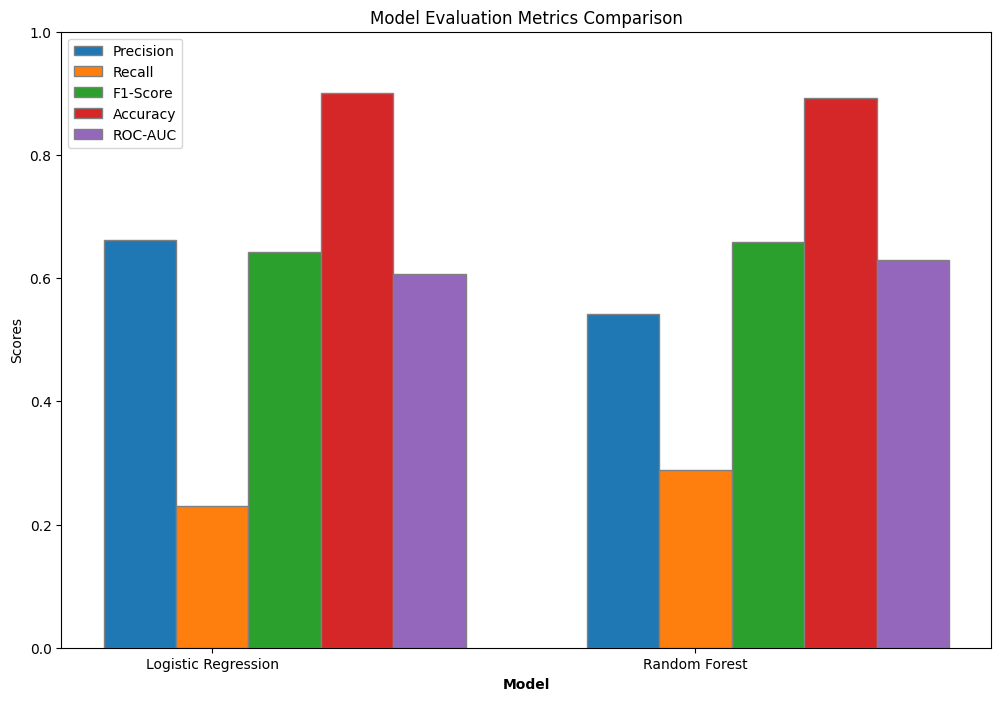

In [105]:
# Define your models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

# Evaluate models
evaluate_models_with_stratified_kfold(models, X_preprocessed.to_numpy(), y_encoded, n_splits=5)

## All features and Class weights and SMOTE oversampling

Evaluating model: Logistic Regression
Average Precision: 0.3431889198472617
Average Recall: 0.6295258620689654
Average F1-Score: 0.6692403489351564
Average Accuracy: 0.8224239373950928
Average ROC-AUC: 0.7382197003156138


Evaluating model: Random Forest
Average Precision: 0.49398189529391734
Average Recall: 0.35387931034482756
Average F1-Score: 0.6746777854584851
Average Accuracy: 0.8863505119914544
Average ROC-AUC: 0.6539152146039487




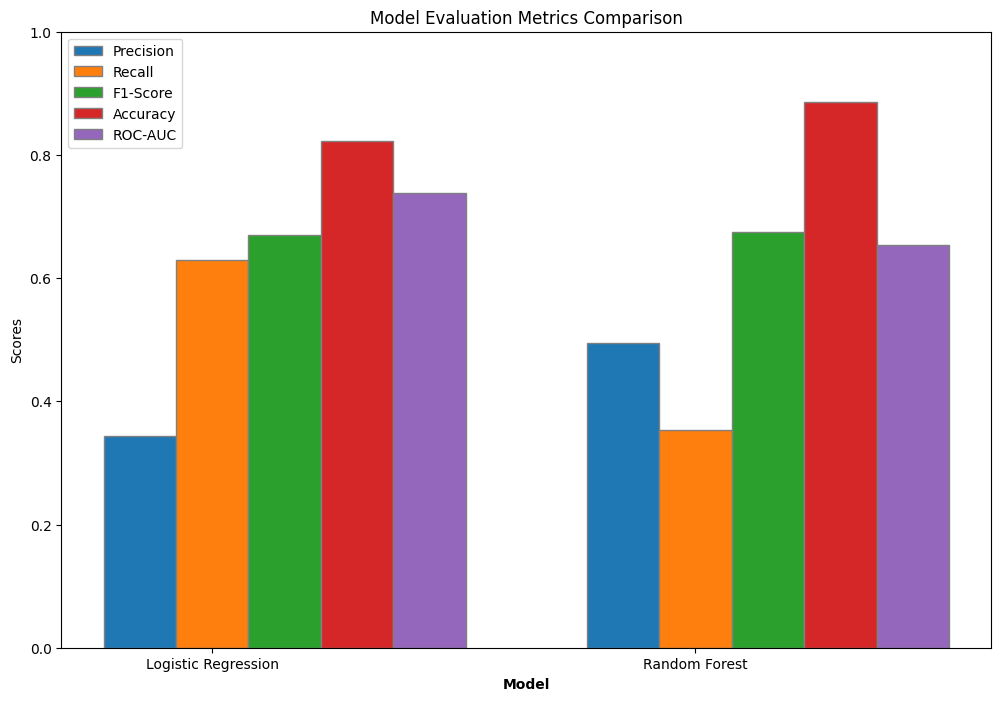

In [106]:
# Define your models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',random_state=42),
}

evaluate_models_with_stratified_kfold(models, X_preprocessed.to_numpy(), y_encoded, n_splits=5, oversample=True)

## Using important features and class weights + SMOTE:

Evaluating model: Logistic Regression
Average Precision: 0.2482929817283329
Average Recall: 0.7051724137931035
Average F1-Score: 0.5962813126773524
Average Accuracy: 0.7262310532626796
Average ROC-AUC: 0.7170385199659661


Evaluating model: Random Forest
Average Precision: 0.39973937863262926
Average Recall: 0.371551724137931
Average F1-Score: 0.6550493610344468
Average Accuracy: 0.8664174963819923
Average ROC-AUC: 0.6503977821985436




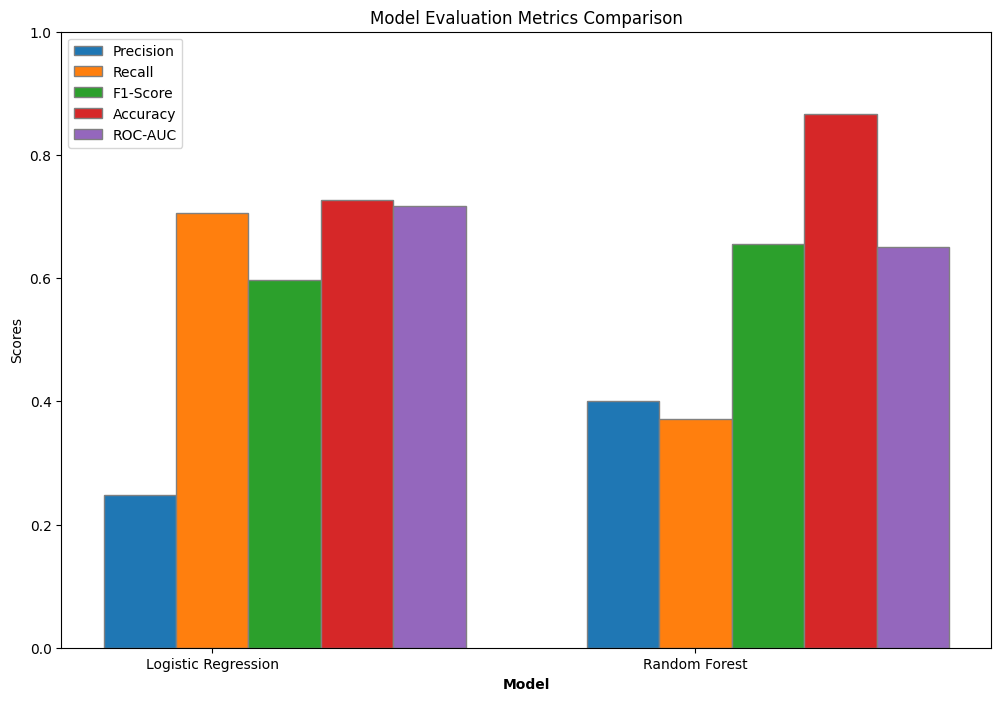

In [107]:
# Define your models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',random_state=42),
}

evaluate_models_with_stratified_kfold(models, X_preprocessed[important_features].to_numpy(), y_encoded, n_splits=5, oversample=True)